# Download additional meteo data from database

Data versions in database:
- meteoscreening_mst = from old (now deprecated) meteo screening tool
- meteoscreening_diive = from meteoscreening using diive

# **Auto-settings**

## Data settings

In [1]:
DIRCONF = r'F:\Sync\luhk_work\20 - CODING\22 - POET\configs'
# DIRCONF = r'P:\Flux\RDS_calculations\_scripts\_configs\configs'  # Folder with configuration files: needed e.g. for connection to database
TIMEZONE_OFFSET_TO_UTC_HOURS = 1  # Timezone, e.g. "1" is translated to timezone "UTC+01:00" (CET, winter time)
REQUIRED_TIME_RESOLUTION = '30min'  # 30MIN time resolution

## Imports

In [2]:
import importlib.metadata
from datetime import datetime
import warnings
warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)

%matplotlib inline
import seaborn as sns
from pathlib import Path
import numpy as np
import pandas as pd

from dbc_influxdb import dbcInflux
from diive.core.io.files import save_parquet
from diive.core.plotting.heatmap_datetime import HeatmapDateTime
from diive.pkgs.corrections.offsetcorrection import remove_radiation_zero_offset

sns.set_theme('notebook')

dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
version_diive = importlib.metadata.version("diive")
print(f"diive version: v{version_diive}")
version_dbc = importlib.metadata.version("dbc_influxdb")
print(f"dbc-influxdb version: v{version_dbc}")
dbc = dbcInflux(dirconf=DIRCONF)  # Connect to database

diive version: v0.87.0
dbc-influxdb version: v0.13.1
Reading configuration files was successful.
Connection to database works.


</br>

# **DOWNLOAD** screened data from the database

In [3]:
# General download settings
download_settings = dict(
    bucket=f'ch-cha_processed',
    measurements=['G', 'LW', 'NETRAD', 'PPFD', 'SW'],
    timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,    
)

## Download meteo version `meteoscreening_diive` (2022-2024)

In [4]:
%%time
meteo_diive_df, data_detailed, assigned_measurements = dbc.download(
    fields=[
        'G_GF1_0.05_1',
        'G_GF1_0.05_2',
        'LW_OUT_T1_2_1',
        'NETRAD_T1_2_1',
        'PPFD_OUT_T1_2_2',
        'SW_OUT_T1_2_1'
    ],
    data_version='meteoscreening_diive',
    start='2022-01-01 00:00:01',  # Download data starting with this date (the start date itself IS included)
    stop='2025-01-01 00:00:01',  # Download data before this date (the stop date itself IS NOT included)
    **download_settings
)


DOWNLOADING
    from bucket ch-cha_processed
    variables ['G_GF1_0.05_1', 'G_GF1_0.05_2', 'LW_OUT_T1_2_1', 'NETRAD_T1_2_1', 'PPFD_OUT_T1_2_2', 'SW_OUT_T1_2_1']
    from measurements ['G', 'LW', 'NETRAD', 'PPFD', 'SW']
    from data version ['meteoscreening_diive']
    between 2022-01-01 00:00:01 and 2025-01-01 00:00:01
    with timezone offset to UTC of 1
Using querystring:
from(bucket: "ch-cha_processed") |> range(start: 2022-01-01T00:00:01+01:00, stop: 2025-01-01T00:00:01+01:00) |> filter(fn: (r) => r["_measurement"] == "G" or r["_measurement"] == "LW" or r["_measurement"] == "NETRAD" or r["_measurement"] == "PPFD" or r["_measurement"] == "SW") |> filter(fn: (r) => r["data_version"] == "meteoscreening_diive") |> filter(fn: (r) => r["_field"] == "G_GF1_0.05_1" or r["_field"] == "G_GF1_0.05_2" or r["_field"] == "LW_OUT_T1_2_1" or r["_field"] == "NETRAD_T1_2_1" or r["_field"] == "PPFD_OUT_T1_2_2" or r["_field"] == "SW_OUT_T1_2_1") |> pivot(rowKey:["_time"], columnKey: ["_field"], val

In [5]:
meteo_diive_df

,G_GF1_0.05_1,G_GF1_0.05_2,LW_OUT_T1_2_1,NETRAD_T1_2_1,PPFD_OUT_T1_2_2,SW_OUT_T1_2_1
TIMESTAMP_END,,,,,,
2022-01-01 00:30:00,-11.242810,-17.538376,310.606803,-30.760217,0.0,0.0
2022-01-01 01:00:00,-11.333304,-16.786064,312.806127,-24.076991,0.0,0.0
2022-01-01 01:30:00,-11.272530,-16.069010,313.400583,-25.581805,0.0,0.0
2022-01-01 02:00:00,-11.107280,-15.390925,311.657540,-37.067527,0.0,0.0
2022-01-01 02:30:00,-10.963630,-15.161179,311.752803,-30.550640,0.0,0.0
...,...,...,...,...,...,...
2024-12-31 22:00:00,-9.097370,-7.880106,311.167160,-5.883538,0.0,0.0
2024-12-31 22:30:00,-9.561669,-8.172388,310.079817,-6.269816,0.0,0.0
2024-12-31 23:00:00,-10.138718,-8.527732,309.604987,-6.934394,0.0,0.0


## Download meteo version `meteoscreening_mst` (2005-2021)

In [6]:
%%time
meteo_mst_df, data_detailed, assigned_measurements = dbc.download(
    fields=[
        'G_GF1_0.03_1',
        'G_GF1_0.03_2',
        'G_GF1_0.05_1',
        'G_GF1_0.05_2',
        'G_GF4_0.02_1',
        'G_GF5_0.02_1',
        'LW_OUT_T1_2_1',
        'NETRAD_T1_2_1',
        'PPFD_OUT_T1_2_2',
        'SW_OUT_T1_2_1'
    ],
    data_version='meteoscreening_mst',
    start='2005-01-01 00:00:01',  # Download data starting with this date (the start date itself IS included)
    stop='2022-01-01 00:00:01',  # Download data before this date (the stop date itself IS NOT included)
    **download_settings
)


DOWNLOADING
    from bucket ch-cha_processed
    variables ['G_GF1_0.03_1', 'G_GF1_0.03_2', 'G_GF1_0.05_1', 'G_GF1_0.05_2', 'G_GF4_0.02_1', 'G_GF5_0.02_1', 'LW_OUT_T1_2_1', 'NETRAD_T1_2_1', 'PPFD_OUT_T1_2_2', 'SW_OUT_T1_2_1']
    from measurements ['G', 'LW', 'NETRAD', 'PPFD', 'SW']
    from data version ['meteoscreening_mst']
    between 2005-01-01 00:00:01 and 2022-01-01 00:00:01
    with timezone offset to UTC of 1
Using querystring:
from(bucket: "ch-cha_processed") |> range(start: 2005-01-01T00:00:01+01:00, stop: 2022-01-01T00:00:01+01:00) |> filter(fn: (r) => r["_measurement"] == "G" or r["_measurement"] == "LW" or r["_measurement"] == "NETRAD" or r["_measurement"] == "PPFD" or r["_measurement"] == "SW") |> filter(fn: (r) => r["data_version"] == "meteoscreening_mst") |> filter(fn: (r) => r["_field"] == "G_GF1_0.03_1" or r["_field"] == "G_GF1_0.03_2" or r["_field"] == "G_GF1_0.05_1" or r["_field"] == "G_GF1_0.05_2" or r["_field"] == "G_GF4_0.02_1" or r["_field"] == "G_GF5_0.02_1" 

In [7]:
meteo_mst_df

,G_GF1_0.03_1,G_GF1_0.03_2,G_GF1_0.05_1,G_GF1_0.05_2,G_GF4_0.02_1,G_GF5_0.02_1,LW_OUT_T1_2_1,NETRAD_T1_2_1,PPFD_OUT_T1_2_2,SW_OUT_T1_2_1
TIMESTAMP_END,,,,,,,,,,
2005-09-09 10:00:00,41.771999,41.953999,NaN,NaN,NaN,NaN,445.067627,309.428986,NaN,97.039001
2005-09-09 10:30:00,35.942001,35.591999,NaN,NaN,NaN,NaN,448.442780,350.565979,NaN,110.169998
2005-09-09 11:00:00,39.693001,37.514000,NaN,NaN,NaN,NaN,457.198303,401.156982,NaN,128.139999
2005-09-09 11:30:00,45.752998,40.192001,NaN,NaN,NaN,NaN,459.623840,365.227020,NaN,118.970001
2005-09-09 12:00:00,49.028999,41.987999,NaN,NaN,NaN,NaN,465.343018,404.110992,NaN,130.660004
...,...,...,...,...,...,...,...,...,...,...
2021-12-31 22:00:00,NaN,NaN,-9.450758,-16.516970,NaN,NaN,309.381137,-46.549667,-2.632380,-4.480845
2021-12-31 22:30:00,NaN,NaN,-9.973918,-16.958338,NaN,NaN,307.929707,-54.259283,-2.629689,-4.238644
2021-12-31 23:00:00,NaN,NaN,-10.410240,-17.496144,NaN,NaN,308.370281,-38.936771,-2.697628,-4.093687


</br>

# Merge variables

In [8]:
meteo_df = pd.concat([meteo_mst_df, meteo_diive_df], axis=0)
meteo_df

,G_GF1_0.03_1,G_GF1_0.03_2,G_GF1_0.05_1,G_GF1_0.05_2,G_GF4_0.02_1,G_GF5_0.02_1,LW_OUT_T1_2_1,NETRAD_T1_2_1,PPFD_OUT_T1_2_2,SW_OUT_T1_2_1
TIMESTAMP_END,,,,,,,,,,
2005-09-09 10:00:00,41.771999,41.953999,NaN,NaN,NaN,NaN,445.067627,309.428986,NaN,97.039001
2005-09-09 10:30:00,35.942001,35.591999,NaN,NaN,NaN,NaN,448.442780,350.565979,NaN,110.169998
2005-09-09 11:00:00,39.693001,37.514000,NaN,NaN,NaN,NaN,457.198303,401.156982,NaN,128.139999
2005-09-09 11:30:00,45.752998,40.192001,NaN,NaN,NaN,NaN,459.623840,365.227020,NaN,118.970001
2005-09-09 12:00:00,49.028999,41.987999,NaN,NaN,NaN,NaN,465.343018,404.110992,NaN,130.660004
...,...,...,...,...,...,...,...,...,...,...
2024-12-31 22:00:00,NaN,NaN,-9.097370,-7.880106,NaN,NaN,311.167160,-5.883538,0.0,0.000000
2024-12-31 22:30:00,NaN,NaN,-9.561669,-8.172388,NaN,NaN,310.079817,-6.269816,0.0,0.000000
2024-12-31 23:00:00,NaN,NaN,-10.138718,-8.527732,NaN,NaN,309.604987,-6.934394,0.0,0.000000


</br>

# Additional corrections

## Remove radiation zero offset from `PPFD_OUT`

[remove_radiation_zero_offset]  running remove_radiation_zero_offset ...


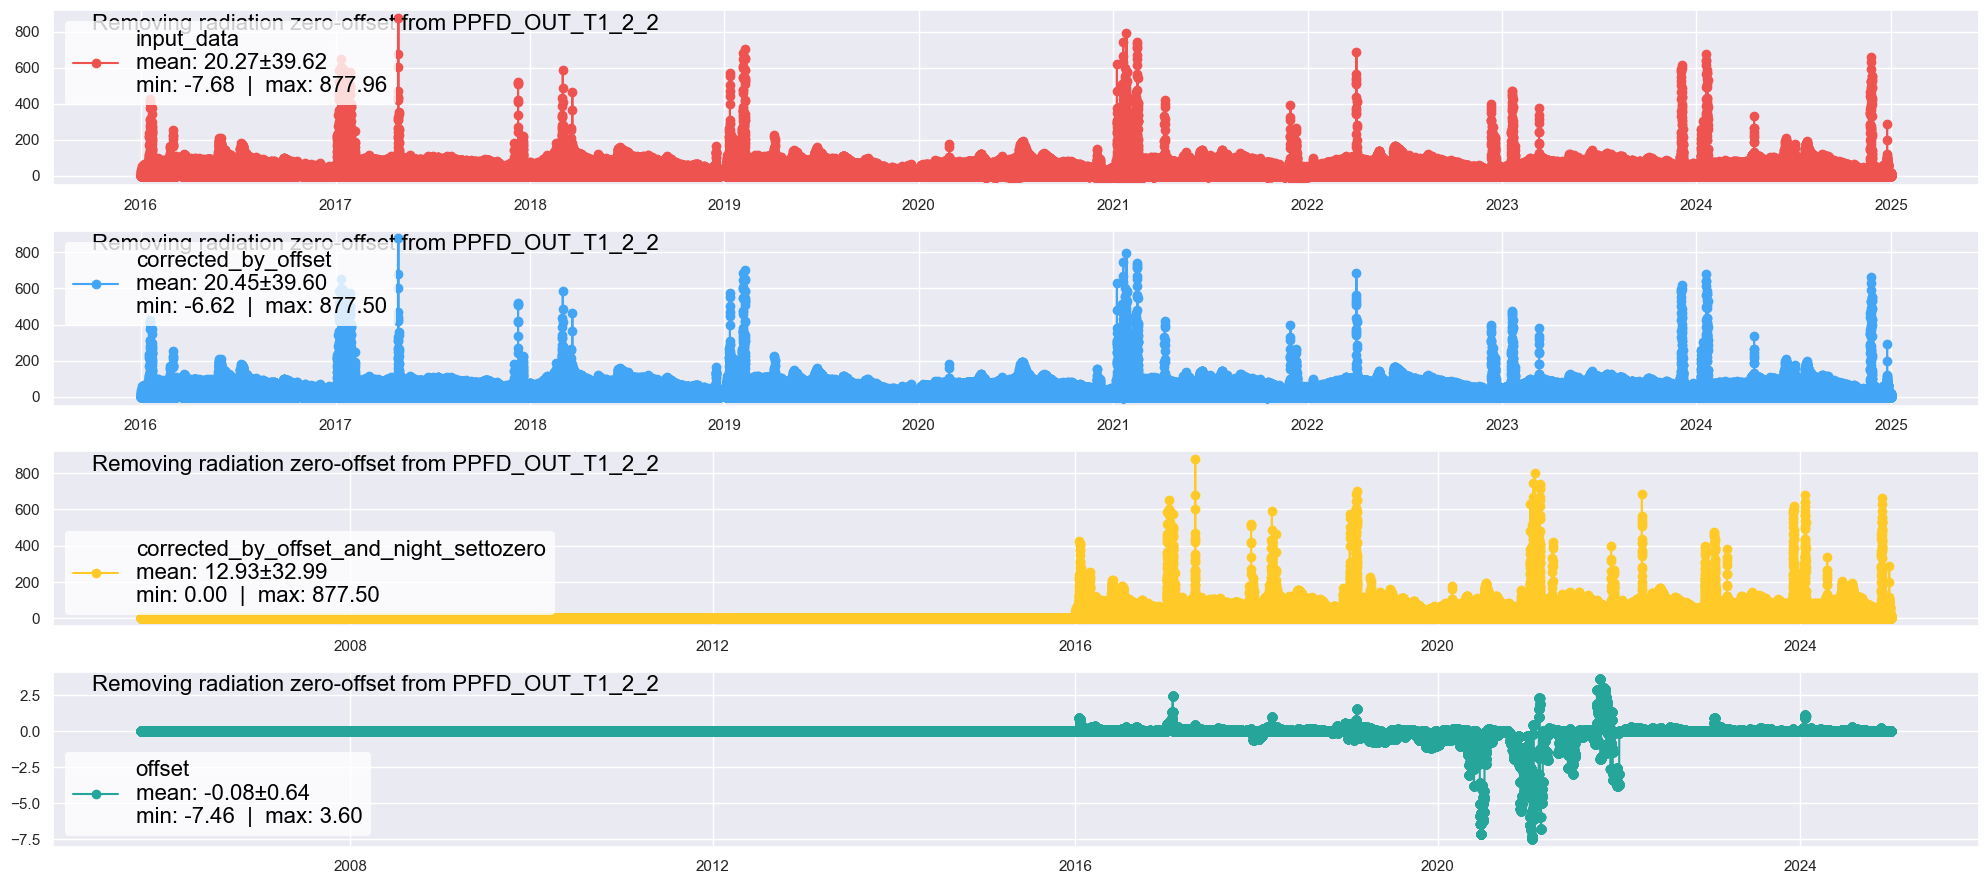

In [9]:
series = meteo_df['PPFD_OUT_T1_2_2'].copy()
series_corr_settozero = remove_radiation_zero_offset(series=series, lat=47.210227, lon=8.410645, utc_offset=1, showplot=True)
meteo_df['PPFD_OUT_T1_2_2'] = np.nan
meteo_df['PPFD_OUT_T1_2_2'] = series_corr_settozero  # Update variable in dataset

## Remove radiation zero offset from `SW_OUT`

[remove_radiation_zero_offset]  running remove_radiation_zero_offset ...


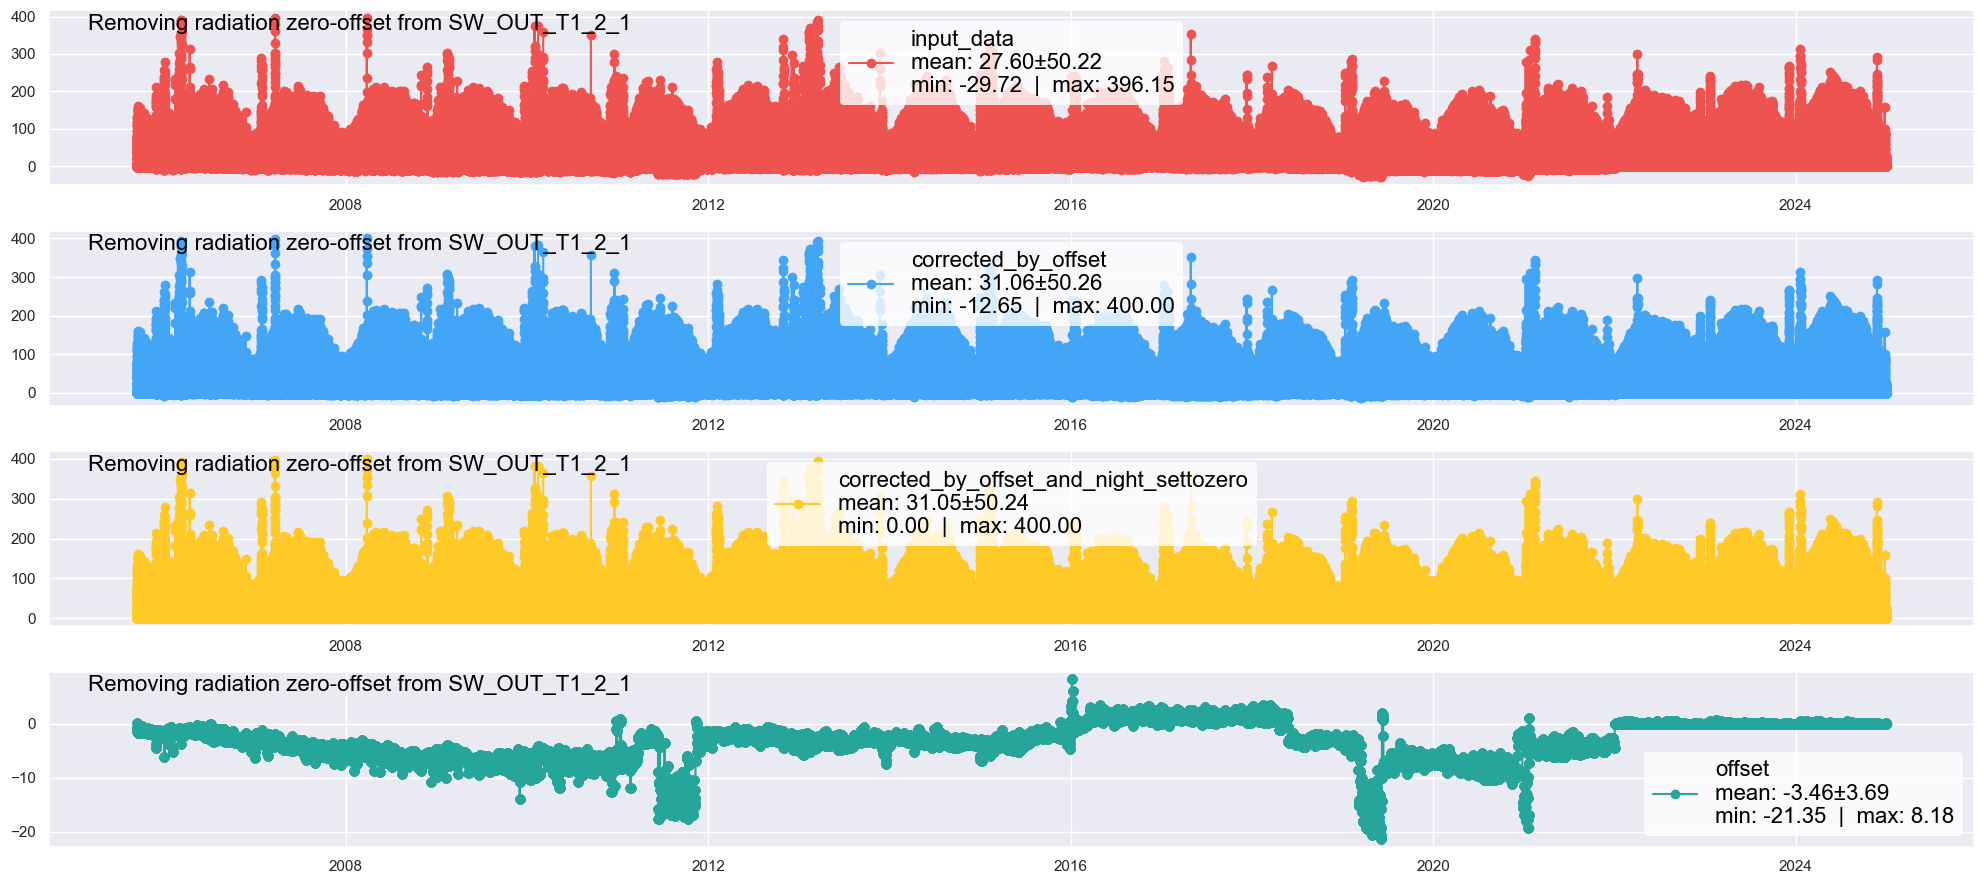

In [10]:
series = meteo_df['SW_OUT_T1_2_1'].copy()
series_corr_settozero = remove_radiation_zero_offset(series=series, lat=47.210227, lon=8.410645, utc_offset=1, showplot=True)
meteo_df['SW_OUT_T1_2_1'] = np.nan
meteo_df['SW_OUT_T1_2_1'] = series_corr_settozero  # Update variable in dataset

</br>

# Plot

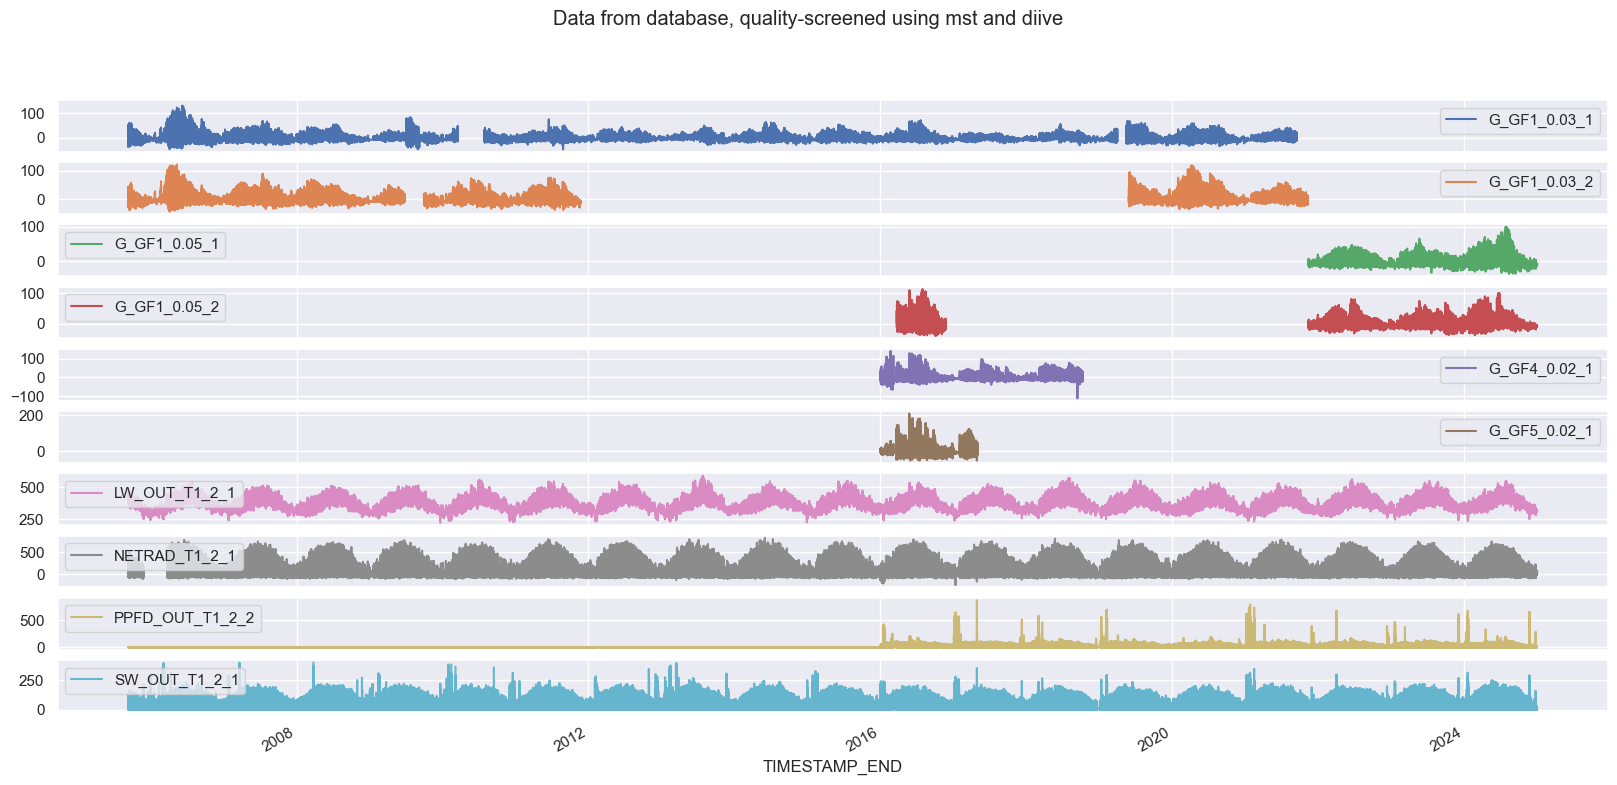

In [11]:
meteo_df.plot(subplots=True, x_compat=True, title="Data from database, quality-screened using mst and diive", figsize=(20, 9));

### Plot: Heatmaps

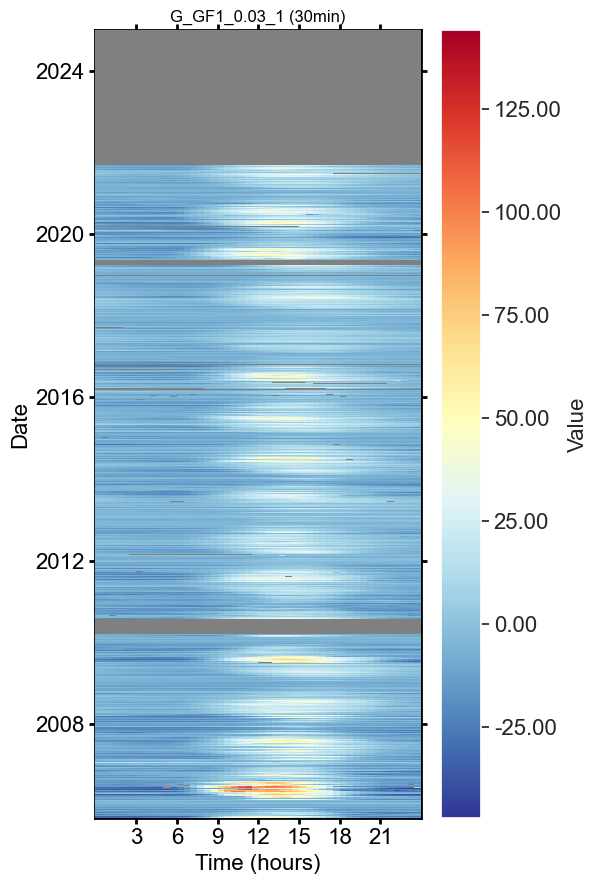

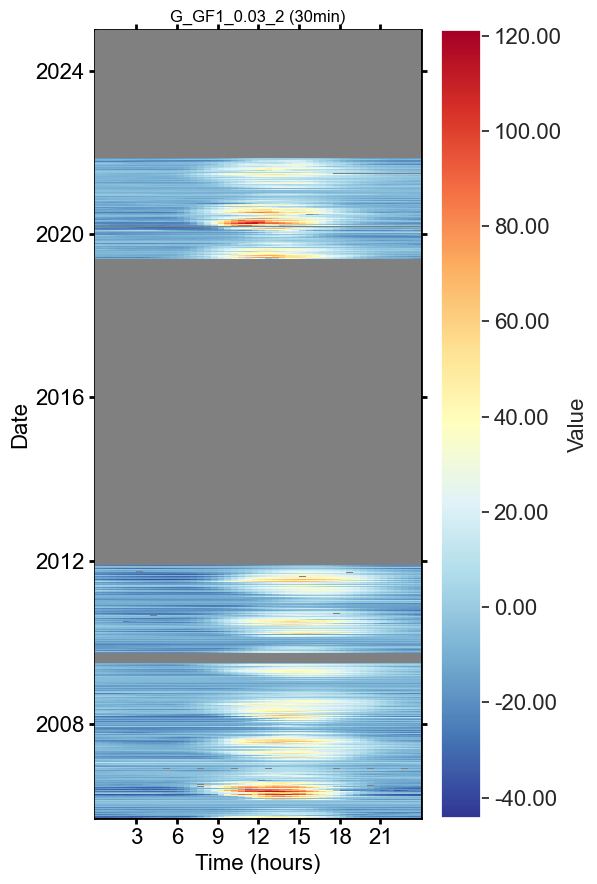

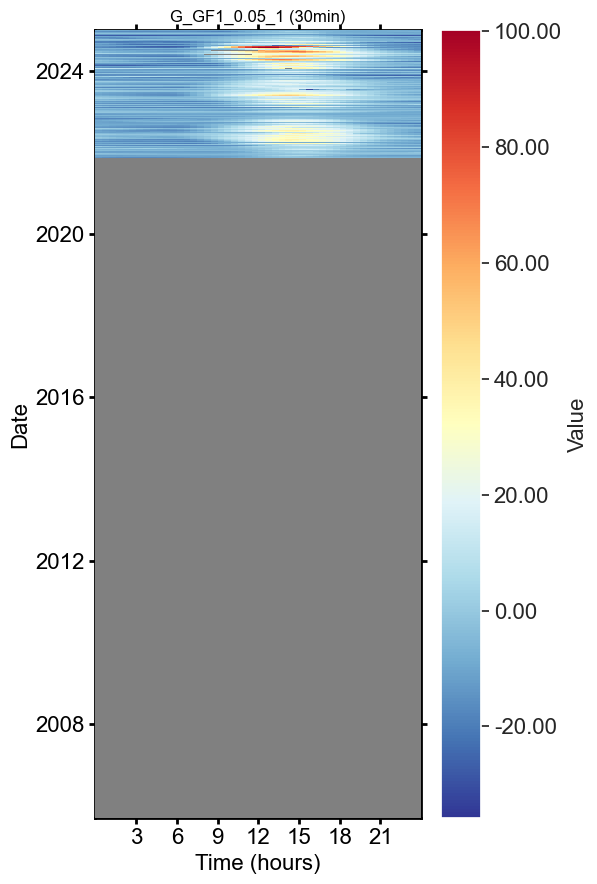

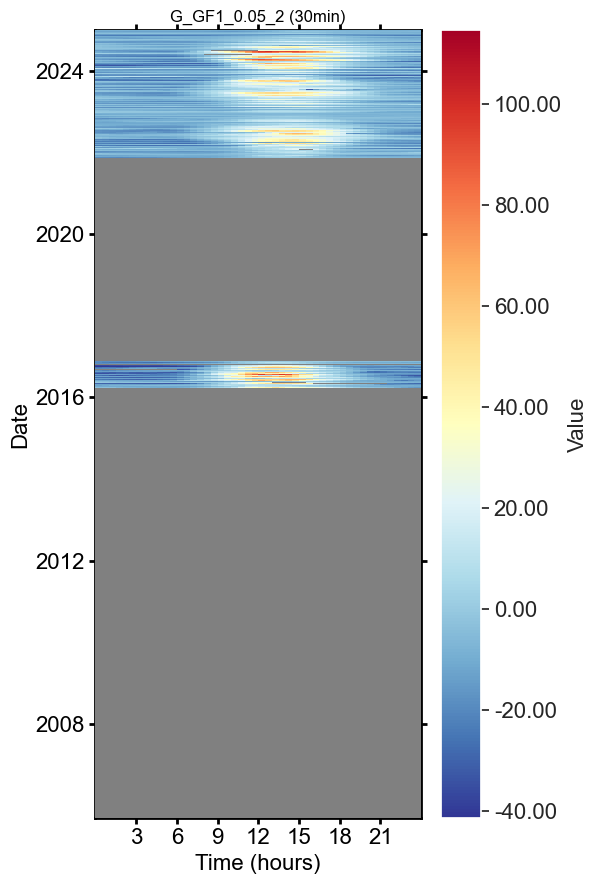

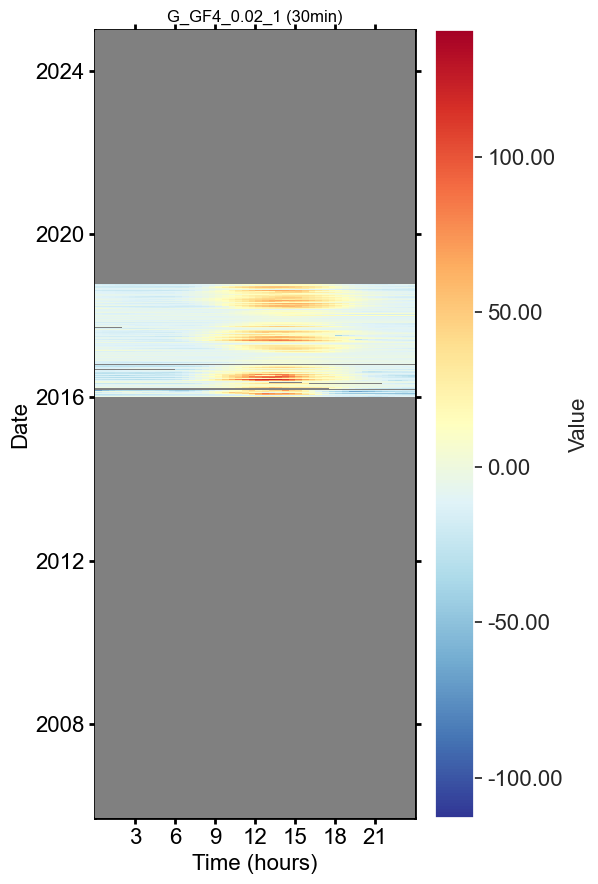

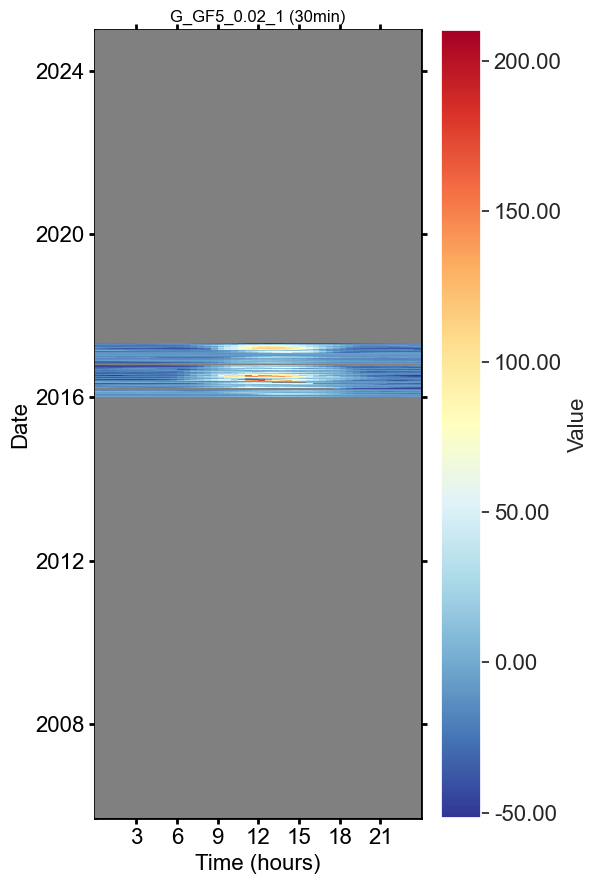

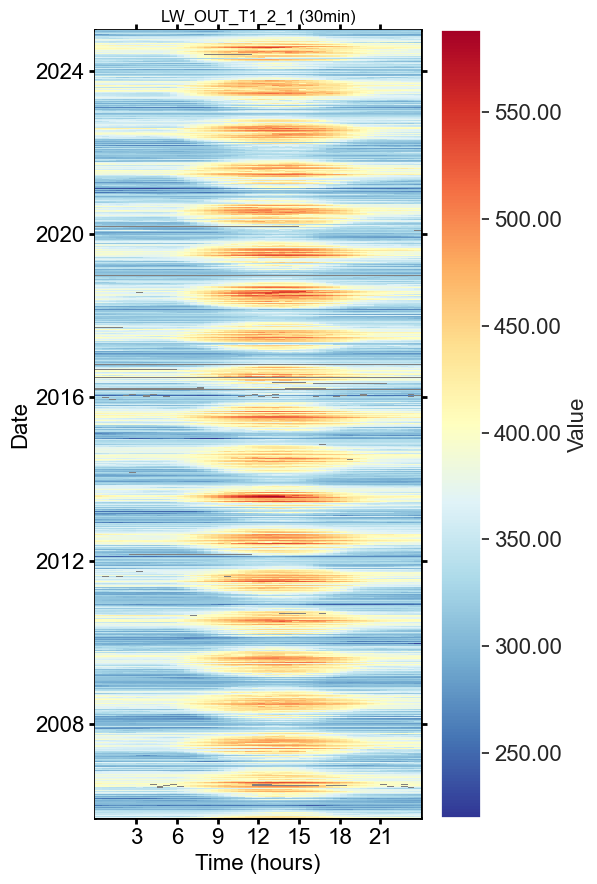

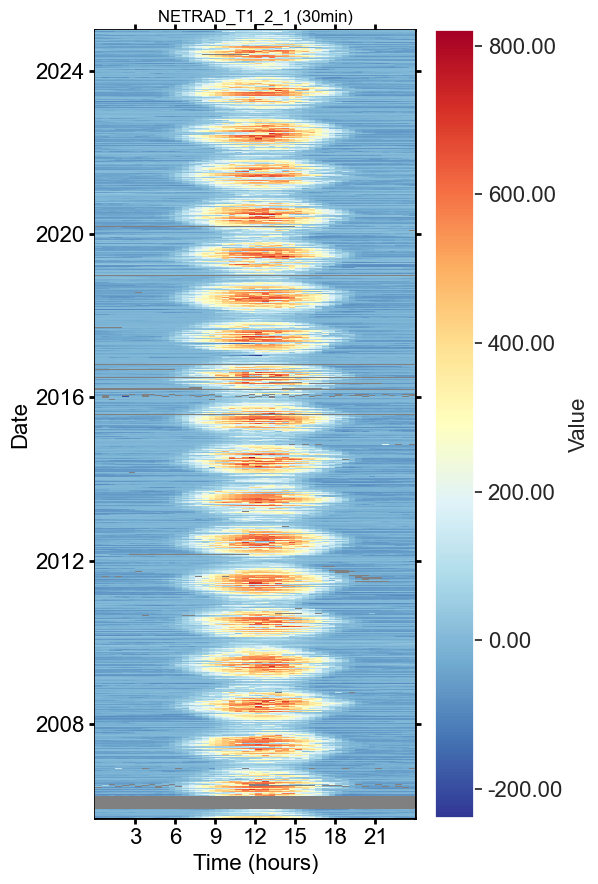

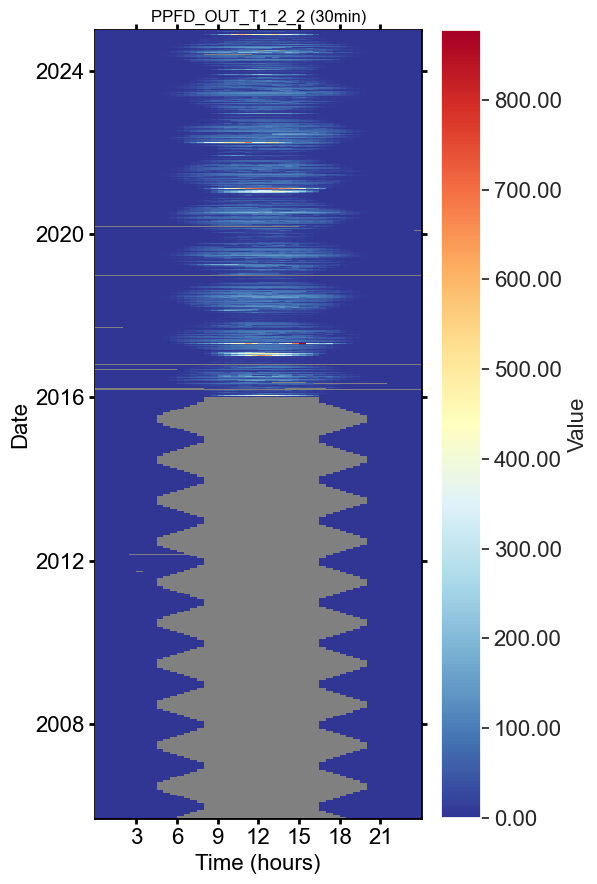

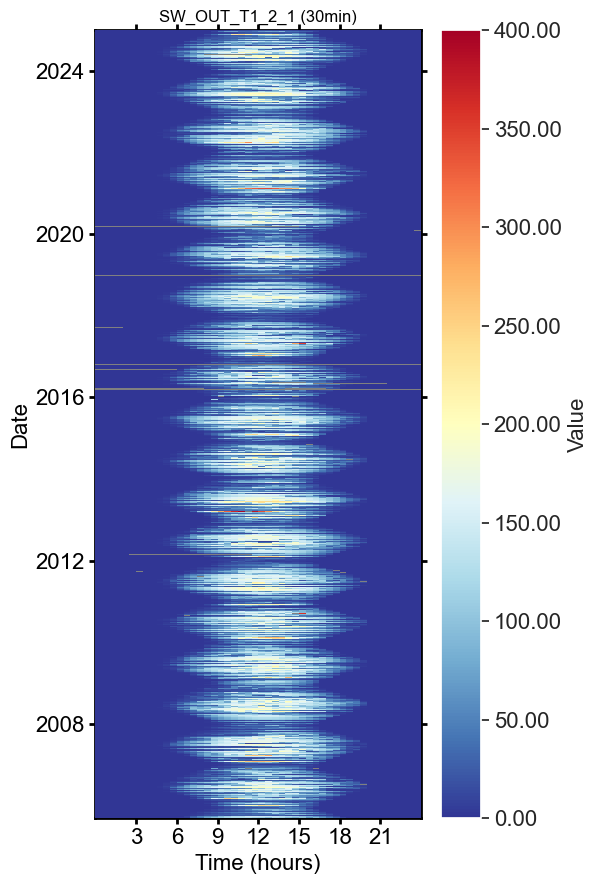

In [12]:
for col in meteo_df.columns:
    series = meteo_df[col]
    series.name = col
    HeatmapDateTime(series, figsize=(6, 9)).show()

</br>

# **Stats**

In [13]:
meteo_df.describe()

,G_GF1_0.03_1,G_GF1_0.03_2,G_GF1_0.05_1,G_GF1_0.05_2,G_GF4_0.02_1,G_GF5_0.02_1,LW_OUT_T1_2_1,NETRAD_T1_2_1,PPFD_OUT_T1_2_2,SW_OUT_T1_2_1
count,269585.000000,146469.000000,54757.000000,66073.000000,47154.000000,22060.000000,334804.000000,327857.000000,246230.000000,335906.000000
mean,-1.193385,-0.577553,-0.270094,-0.342612,0.641871,-0.283611,364.470743,71.055922,12.930431,31.045693
std,12.963156,17.132764,14.754008,18.143960,19.810565,30.623602,49.851821,160.981227,32.990131,50.235830
min,-47.055000,-44.280998,-35.804811,-41.417007,-113.034272,-51.693900,219.459778,-239.564892,0.000000,0.000000
25%,-8.695100,-10.853000,-9.471208,-11.079020,-10.687745,-17.098853,325.798793,-24.762987,0.000000,0.000000
50%,-3.945100,-5.171900,-3.830321,-4.648535,-4.932843,-8.082744,358.038179,1.558916,0.000000,0.000000
75%,3.492906,4.951200,5.004128,5.863855,6.489021,6.695478,394.528016,102.369980,6.733083,43.763341
max,144.000000,121.099998,100.162337,114.592513,140.847467,210.062867,588.454834,820.841980,877.499474,400.000424


</br>

# **SAVE TO FILE**

In [14]:
OUTNAME = "18.1_CH-CHA_METEO_G_LWOUT_PPFDOUT_SWOUT_NETRAD_2004-2024"
OUTPATH = r""
filepath = save_parquet(filename=OUTNAME, data=meteo_df, outpath=OUTPATH)
# meteo_df.to_csv(Path(OUTPATH) / f"{OUTNAME}.csv")

Saved file 18.1_CH-CHA_METEO_G_LWOUT_PPFDOUT_SWOUT_NETRAD_2004-2024.parquet (0.179 seconds).


</br>

# **End of notebook**.

In [15]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")

Finished. 2025-05-14 12:11:35


</br>